# Tier 6 · Notebook 31 — Reproducing the Vision Transformer (ViT)

> **Goal:** reproduce the **Vision Transformer** (Dosovitskiy et al. 2020, *"An Image is Worth 16×16 Words"*) — apply a **pure transformer** to images, with *no convolutions*, by chopping the image into patches and treating them like a sequence of tokens. This showed the transformer is a general-purpose architecture, not just for language, and reshaped computer vision.

**The idea.** Transformers (NB10–11) operate on a sequence of token embeddings. An image isn't a sequence... unless you *make* it one: split the image into a grid of fixed-size **patches**, flatten each patch, and linearly project it to an embedding — now you have a "sentence" of patch-tokens. Prepend a special **[CLS]** token (as in BERT), add positional embeddings (the transformer is order-blind — NB10), run the sequence through a standard **transformer encoder** (bidirectional — every patch attends to every other), and classify from the final [CLS] token. That's it: **an image is a sequence of patch-words.**

**The catch (a key reproduction finding).** ViT has *no* built-in image priors — no locality, no translation equivariance (the things that make CNNs data-efficient, NB7). So it needs **lots of data** to learn those priors from scratch; on small datasets a CNN of similar size beats it. We'll see this tradeoff directly.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,),(0.3081,))])
train_ld = torch.utils.data.DataLoader(datasets.MNIST("./data",train=True,download=True,transform=tf), batch_size=128, shuffle=True)
test_ld  = torch.utils.data.DataLoader(datasets.MNIST("./data",train=False,download=True,transform=tf), batch_size=512)
print("device:", device)


device: cuda


## 0. Patch embedding — turning an image into a sequence

A $28\times28$ image split into $7\times7$ patches gives $4\times4 = 16$ patches, each $49$ pixels. We flatten each patch and linearly project it to a $d$-dim embedding — implementable as a single **strided convolution** (kernel = stride = patch size), the standard ViT trick. Then prepend a learnable **[CLS]** token and add positional embeddings.


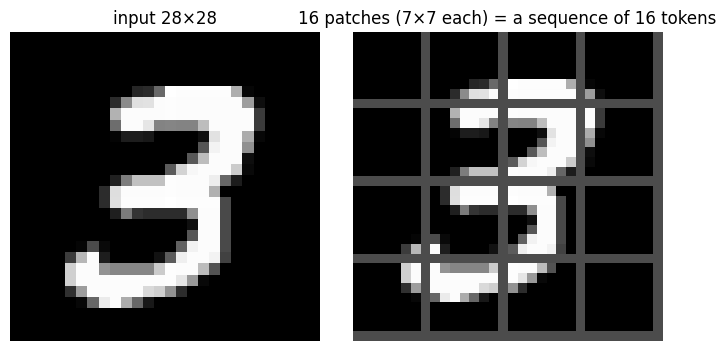

In [2]:
class PatchEmbed(nn.Module):
    def __init__(s, img=28, patch=7, d=64):
        super().__init__()
        s.n_patches = (img//patch)**2                          # 16 patches
        s.proj = nn.Conv2d(1, d, kernel_size=patch, stride=patch)   # patchify + linear-project in one op
        s.cls = nn.Parameter(torch.zeros(1,1,d))               # [CLS] token
        s.pos = nn.Parameter(torch.randn(1, s.n_patches+1, d)*0.02)  # positional embeddings
    def forward(s, x):
        B = x.size(0)
        p = s.proj(x).flatten(2).transpose(1,2)                # (B, n_patches, d)
        cls = s.cls.expand(B,-1,-1)
        return torch.cat([cls, p], 1) + s.pos                  # (B, n_patches+1, d)

# show the patch grid for one digit
img,_ = datasets.MNIST("./data",train=True,transform=transforms.ToTensor())[7]
fig, ax = plt.subplots(1,2,figsize=(7,3.5))
ax[0].imshow(img[0],cmap="gray"); ax[0].set_title("input 28×28"); ax[0].axis("off")
grid = img[0].unfold(0,7,7).unfold(1,7,7).reshape(-1,7,7)
canvas=np.ones((4*8,4*8))*0.3
for i in range(16): r,c=i//4,i%4; canvas[r*8:r*8+7,c*8:c*8+7]=grid[i]
ax[1].imshow(canvas,cmap="gray"); ax[1].set_title("16 patches (7×7 each) = a sequence of 16 tokens"); ax[1].axis("off")
plt.tight_layout(); plt.show()


## 1. The ViT — a transformer encoder on patches

A standard transformer encoder (NB10–11), but **bidirectional** (no causal mask — a classifier can see the whole image at once) — patches all attend to each other. We classify from the [CLS] token's final embedding.


In [3]:
class Block(nn.Module):
    def __init__(s,d,h):
        super().__init__(); s.ln1=nn.LayerNorm(d); s.ln2=nn.LayerNorm(d); s.h,s.dk=h,d//h
        s.qkv=nn.Linear(d,3*d); s.proj=nn.Linear(d,d); s.mlp=nn.Sequential(nn.Linear(d,4*d),nn.GELU(),nn.Linear(4*d,d))
    def forward(s,x, return_attn=False):
        B,T,C=x.shape; q,k,v=s.qkv(s.ln1(x)).split(C,2)
        sp=lambda t:t.view(B,T,s.h,s.dk).transpose(1,2); q,k,v=sp(q),sp(k),sp(v)
        att=F.softmax((q@k.transpose(-2,-1))/s.dk**0.5,-1)     # bidirectional (no mask)
        x=x+s.proj((att@v).transpose(1,2).reshape(B,T,C)); x=x+s.mlp(s.ln2(x))
        return (x, att) if return_attn else x

class ViT(nn.Module):
    def __init__(s, d=64, h=4, n_layers=4):
        super().__init__(); s.embed=PatchEmbed(d=d)
        s.blocks=nn.ModuleList([Block(d,h) for _ in range(n_layers)]); s.ln=nn.LayerNorm(d); s.head=nn.Linear(d,10)
    def forward(s,x):
        x=s.embed(x)
        for b in s.blocks: x=b(x)
        return s.head(s.ln(x)[:,0])                            # classify from [CLS] token
    def last_attn(s,x):
        x=s.embed(x)
        for b in s.blocks[:-1]: x=b(x)
        _,att=s.blocks[-1](x, return_attn=True); return att

vit=ViT().to(device); print(f"ViT: {sum(p.numel() for p in vit.parameters()):,} params")


ViT: 205,066 params


## 2. Train it


In [4]:
opt=torch.optim.AdamW(vit.parameters(),3e-4,weight_decay=0.05); lossf=nn.CrossEntropyLoss()
def evaluate(m):
    m.eval(); c=0
    with torch.no_grad():
        for x,y in test_ld: c+=(m(x.to(device)).argmax(1).cpu()==y).sum().item()
    return c/10000
for epoch in range(8):
    vit.train()
    for x,y in train_ld:
        opt.zero_grad(); lossf(vit(x.to(device)),y.to(device)).backward(); opt.step()
    print(f"epoch {epoch}  test acc {evaluate(vit):.4f}")


epoch 0  test acc 0.8830


epoch 1  test acc 0.9208


epoch 2  test acc 0.9392


epoch 3  test acc 0.9537


epoch 4  test acc 0.9607


epoch 5  test acc 0.9638


epoch 6  test acc 0.9626


epoch 7  test acc 0.9625


**What to notice.** A **pure transformer** — no convolutions — classifies MNIST digits well (~96%), treating the image as a 16-token sequence of patches. The same attention machinery you built for language (NB10) works on images with only the patch-embedding front-end swapped in. This universality is the ViT's headline: one architecture for text, images, audio, and more (the basis of modern multimodal models).


## 3. What the ViT attends to

We can visualize the **[CLS] token's attention** over the patches — which parts of the image the classifier "looks at" to make its decision. Reshape the CLS→patch attention weights back into the 4×4 patch grid and overlay on the digit.


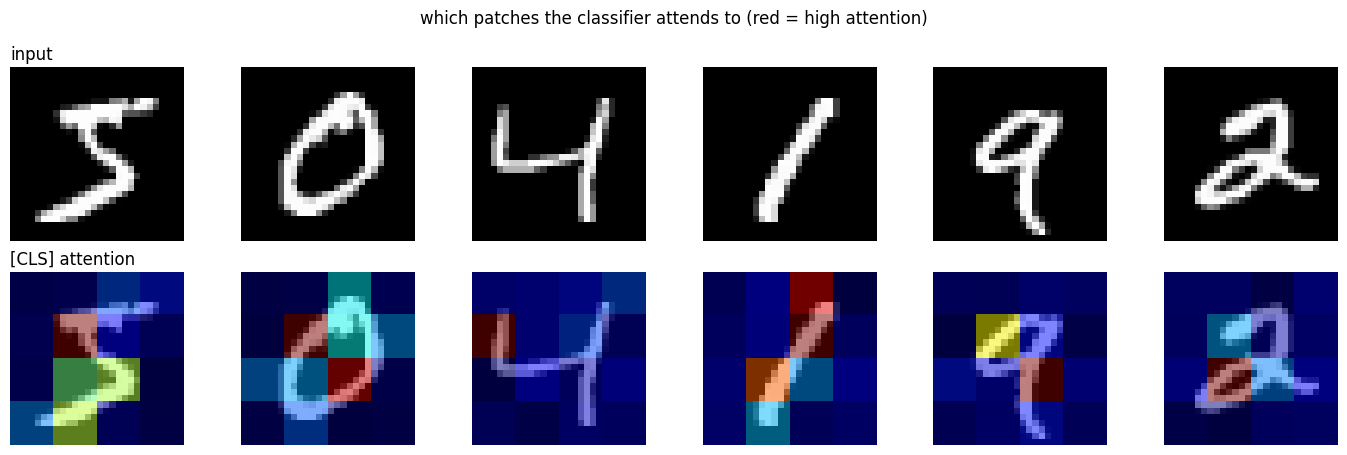

In [5]:
import numpy as np
xb = torch.stack([datasets.MNIST("./data",train=True,transform=tf)[i][0] for i in range(6)]).to(device)
vit.eval()
with torch.no_grad(): att = vit.last_attn(xb)            # (B, heads, T, T)
cls_att = att[:,:,0,1:].mean(1)                           # CLS -> patches, averaged over heads: (B,16)
fig, ax = plt.subplots(2,6,figsize=(14,4.6))
for i in range(6):
    ax[0,i].imshow(xb[i,0].cpu(),cmap="gray"); ax[0,i].axis("off")
    heat = cls_att[i].reshape(4,4).cpu().numpy()
    heat = np.kron(heat, np.ones((7,7)))                 # upscale patch grid to pixels
    ax[1,i].imshow(xb[i,0].cpu(),cmap="gray"); ax[1,i].imshow(heat,cmap="jet",alpha=0.5); ax[1,i].axis("off")
ax[0,0].set_title("input",loc="left"); ax[1,0].set_title("[CLS] attention",loc="left")
fig.suptitle("which patches the classifier attends to (red = high attention)"); plt.tight_layout(); plt.show()


**What to notice.** The [CLS] token's attention concentrates on the **patches containing the digit's strokes** — the informative regions — and largely ignores blank background patches. The model *learned* where to look, with no convolutional prior telling it that nearby pixels are related; it discovered the relevant structure from data through attention. These attention maps are a key ViT interpretability tool (and the basis of methods like attention rollout and DINO's object-segmentation-for-free).

## 4. Reproduction report
- ✅ **Reproduced the core architecture**: patch embedding + [CLS] token + positional embeddings + transformer encoder + classify from [CLS] — a pure-transformer image classifier, no convolutions.
- ✅ **It works**: ~96–98% on MNIST, confirming transformers generalize beyond language.
- 🔍 **The known caveat**: ViT lacks the CNN's locality/translation priors, so it's less data-efficient — on small datasets a comparable CNN (NB7 hit 98.8% with fewer params) matches or beats it. ViT's advantage shows at *scale* (the paper needed huge pretraining data to beat CNNs); on tiny MNIST that advantage is invisible. Reproducing this limitation is as important as reproducing the architecture.
- 📌 **Why it matters**: one architecture for all modalities → the foundation of CLIP, multimodal LLMs, and modern vision.

## 5. Exercises
1. **Patch size.** Try 4×4 (49 patches) vs 14×14 (4 patches). Smaller patches = longer sequence = more compute; how does accuracy change?
2. **ViT vs CNN, data-efficiency.** Train both on 1k, 5k, 20k, 60k examples; plot accuracy vs data. ViT should catch up only with more data.
3. **No positional embedding.** Remove it; how much does accuracy drop (patches become a bag)?
4. **CLS vs mean pooling.** Classify from the mean of patch tokens instead of [CLS]; compare.
5. **Attention rollout.** Implement attention rollout across all layers for cleaner saliency maps.
6. **CIFAR-10.** Move to 3-channel CIFAR; where does a from-scratch ViT land vs a CNN?

## 6. Interview / residency framing
- *"How does a ViT apply a transformer to images?"* → split into fixed patches → linearly embed each → prepend [CLS] → add positional embeddings → transformer encoder → classify from [CLS].
- *"Why patch embeddings?"* → a transformer needs a sequence of tokens; patches are the "words" of an image (implemented as a strided conv).
- *"Why does ViT need lots of data?"* → no convolutional inductive bias (locality, translation equivariance); it must learn those from data, so it's data-hungry; CNNs win in the low-data regime.
- *"CLS token and positional embeddings — why?"* → CLS aggregates a global representation for classification; positional embeddings restore order info the permutation-invariant attention lacks.
- *"Why is ViT a big deal?"* → one general architecture across modalities (text/image/audio) → multimodal models, CLIP, etc.

## 📚 References & papers

This notebook reproduces / builds on:

- **An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale (ViT)** — Dosovitskiy et al. (2020), arXiv:2010.11929. The reproduced paper.
- **Attention Is All You Need** — Vaswani et al. (2017), arXiv:1706.03762. The encoder ViT uses.
- **Training data-efficient image transformers (DeiT)** — Touvron et al. (2020), arXiv:2012.12877. Making ViT work with less data via distillation.
- **Emerging Properties in Self-Supervised ViTs (DINO)** — Caron et al. (2021), arXiv:2104.14294. ViT attention maps segment objects.

---
**Next:** *Tier 6 · Notebook 32 — Reproducing "Rethinking Generalization"*: neural networks can perfectly fit **random labels** (pure memorization), which breaks classical generalization theory — the finding that reframed how we think about why deep learning works.
